<a href="https://colab.research.google.com/github/praveenkumarchandaliya/STTP_Program/blob/MetaLearning/CLIP_Tutorial_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**https://www.youtube.com/watch?v=qwDfYBdkxJQ&t=26s**

In [ ]:
import torch
import numpy as np
from typing import List, Any

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [ ]:
import random

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

In [ ]:
from abc import ABC, abstractmethod
import torch.nn as nn


class ImageEncoder(nn.Module, ABC):
    """Abstract base class for all image encoders."""
    def __init__(self, d_i: int):
        super().__init__()
        self.d_i = d_i

    @abstractmethod
    def encode(self, I:torch.Tensor):  # Taking Image
        pass

class TextEncoder(ABC):
    """Abstract base class for all text encoders."""
    def __init__(self, d_t: int):
        super().__init__()
        self.d_t = d_t

    @abstractmethod
    def encode(self, T:torch.Tensor):
        pass


class DummyImageEncoder(ImageEncoder):
    def __init__(self, d_i: int):
        super().__init__(d_i)

    def encode(self, I:torch.Tensor):
        return torch.randn(I.size(0), self.d_i, device=device)


class DummyTextEncoder(TextEncoder):
    def __init__(self, d_t: int):
        super().__init__(d_t)

    def encode(self, T:torch.Tensor):
        return torch.randn(T.size(0), self.d_t, device=device)



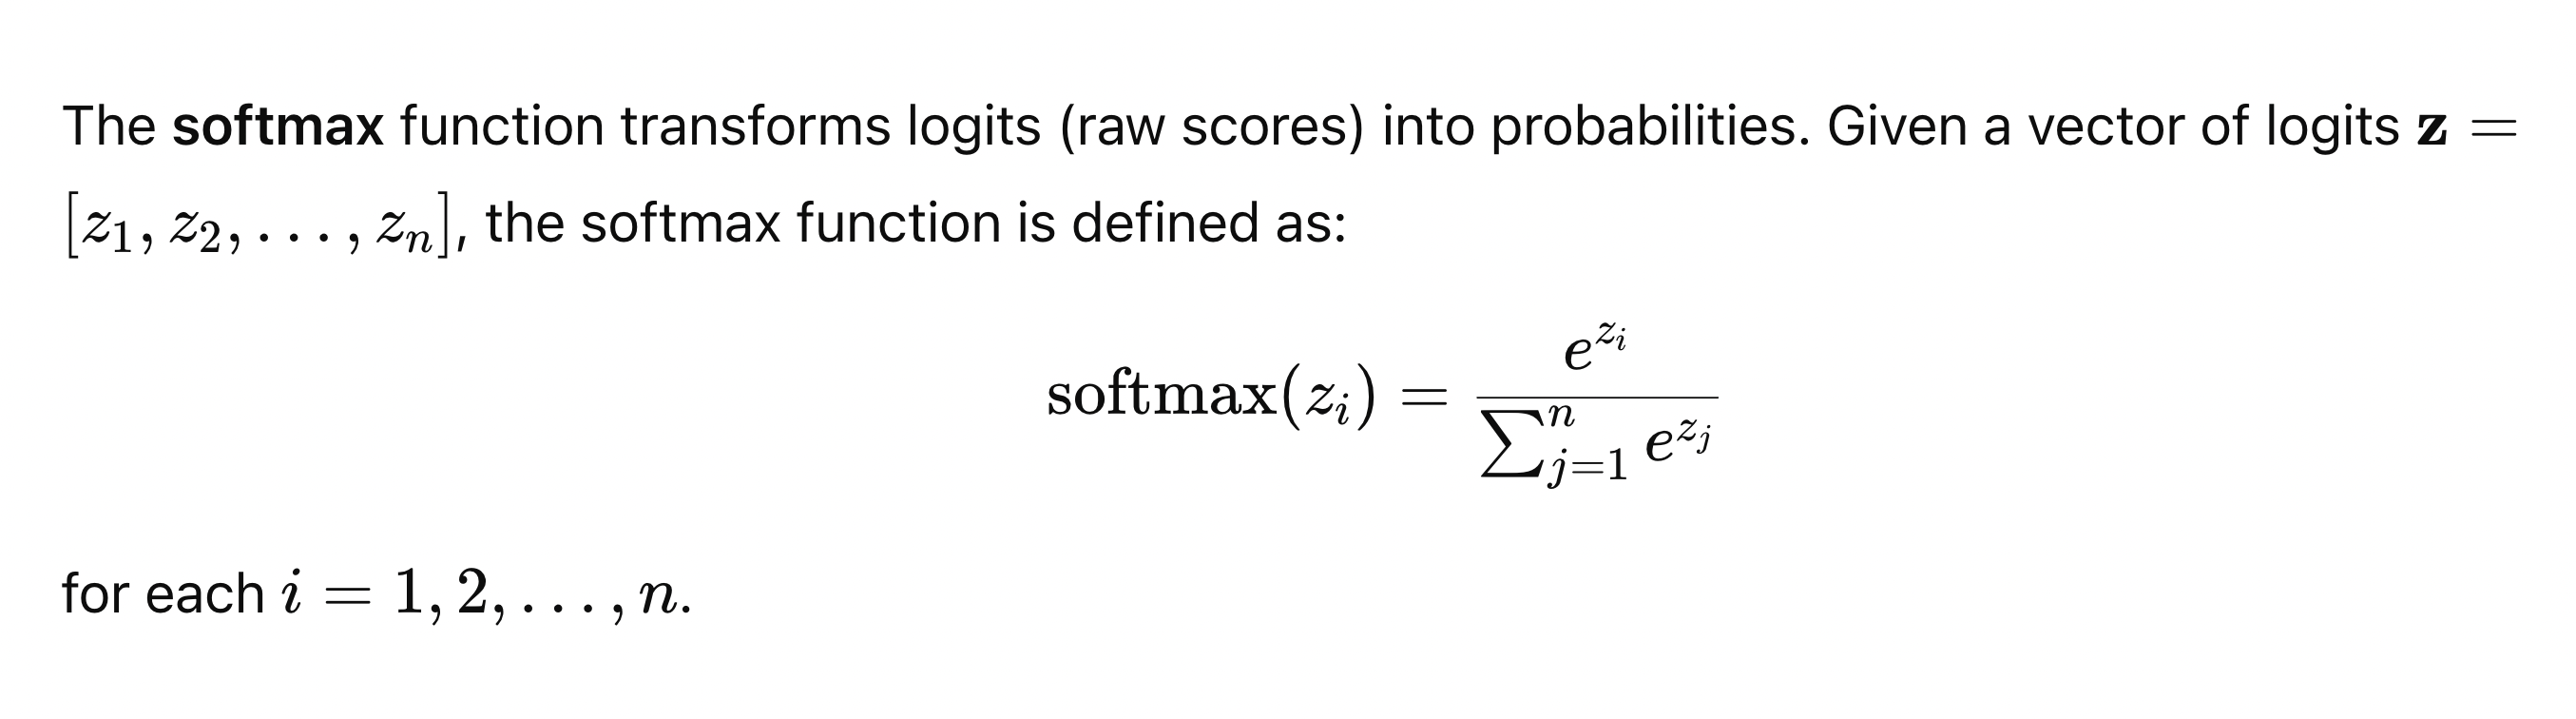

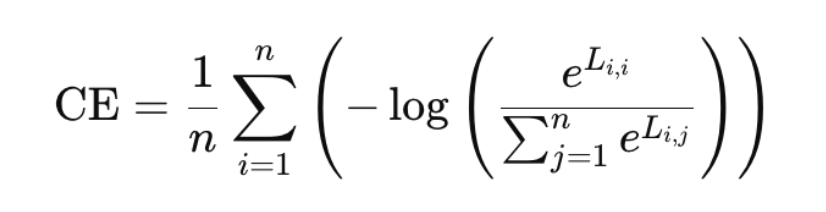

In [ ]:
def l2_norm(tensor: torch.tensor):
    return torch.nn.functional.normalize(tensor, dim=1)  #normalizes each row (because dim=1) so that its L2 norm equals 1.


def softmax(logits: torch.Tensor):
    # logits = torch.tensor([[2.0, 1.0, 0.1]])
    shifted_logits = logits - logits.max(dim=1, keepdim=True).values #  Find maximum value in each row and dim=1 For classification networks, logits often have shape.
    #tensor([[2.0]]) # Max Value
    # shifted_logits =[[2.0, 1.0, 0.1]] - [[2.0]]
    # [[0.0, -1.0, -1.9]]

    logits_exp = torch.exp(shifted_logits)
    # e0,e−1,e−1.9
    # tensor([[1.0000, 0.3679, 0.1496]])
    return logits_exp / logits_exp.sum(dim=1, keepdim=True)


def calc_cross_entropy(logits_softmax):
    '''
    logits_softmax =
    tensor([
    [0.80, 0.10, 0.10],
    [0.05, 0.90, 0.05],
    [0.20, 0.10, 0.70]
    ])
    '''
    diagonal = logits_softmax.diag()
    #tensor([0.80, 0.90, 0.70]) # These represent the probabilities assigned to the correct class/matching pair.
    return -torch.log(diagonal).mean()  # Compute Log Probabilities
    # tensor([-0.2231,-0.1054,-0.3567])


def calc_clip_cross_entropy_loss(logits_image:torch.Tensor, logits_text: torch.Tensor, ):
    loss_image = calc_cross_entropy(softmax(logits_image)) #  Image
    loss_text = calc_cross_entropy(softmax(logits_text))    #  Text

    return (loss_image + loss_text) / 2

### Following test fails with current implementation of softmax and cross entropy
*log(0) = Inf*

In [ ]:
def test_cross_entropy():
    logits_softmax = torch.tensor([
        [0.0, 0.5, 0.5],
        [0.25, 0.25, 0.25],
        [0.2, 0.5, 0.3]
    ])
    ce = calc_cross_entropy(logits_softmax)
    print (ce)

test_cross_entropy()

tensor(inf)


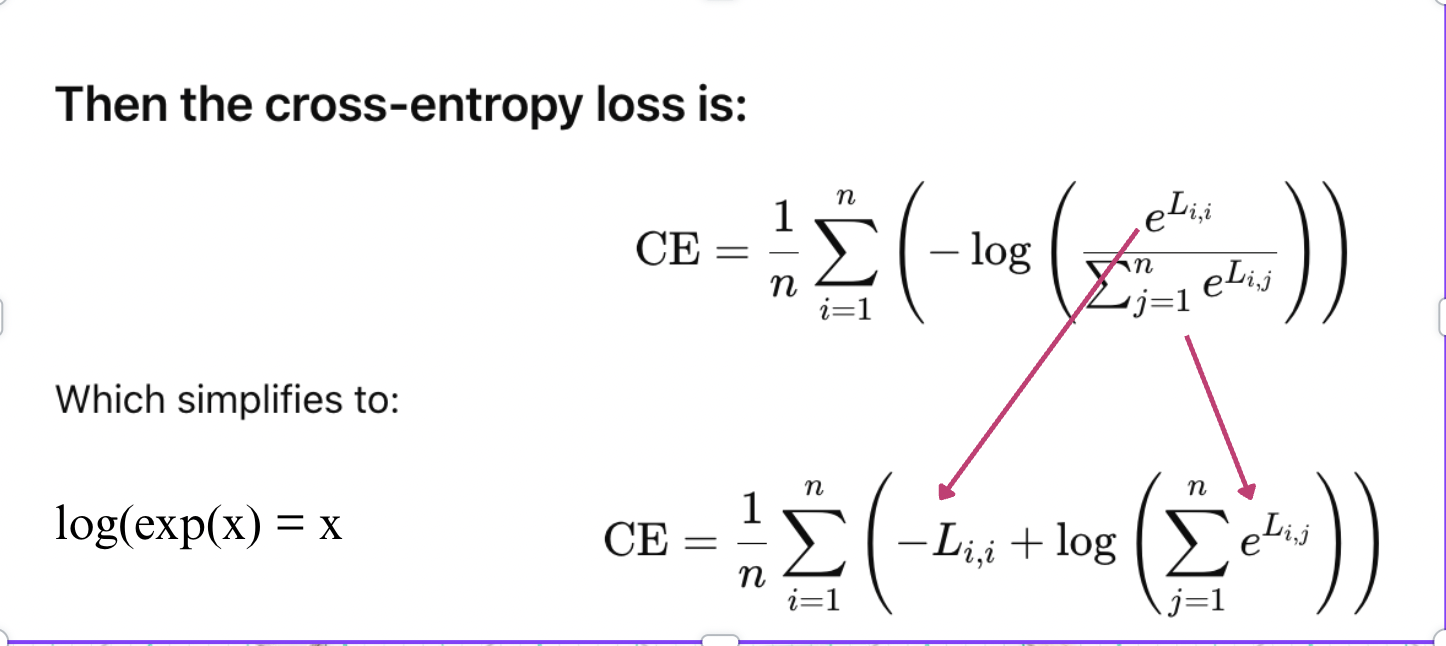

In [ ]:
def calc_cross_entropy(logits: torch.Tensor, targets: torch.Tensor):
    """Numerically stable implementation of softmax followed by cross entropy."""
    logsumexp = torch.logsumexp(logits, dim=1)
    nll = -logits[range(logits.size(0)), targets] + logsumexp

    return nll.mean()
## This symmetric contrastive loss is the key idea behind CLIP and enables learning powerful multimodal representations without explicit class labels
def calc_clip_cross_entropy_loss(logits_image:torch.Tensor, logits_text: torch.Tensor, targets: torch.Tensor):
    loss_image = calc_cross_entropy(logits_image, targets) #Image → Text:
    loss_text = calc_cross_entropy(logits_text, targets) # Text → Image:

    return (loss_image + loss_text) / 2

In [ ]:

def test_cross_entropy():
    logits = torch.tensor([
        [0.0, 0.5, 0.5],
        [0.25, 0.25, 0.25],
        [0.2, 0.5, 0.3]
    ])
    ce = calc_cross_entropy(logits, targets=range(logits.size(0)))
    print (ce)

test_cross_entropy()

tensor(1.2322)


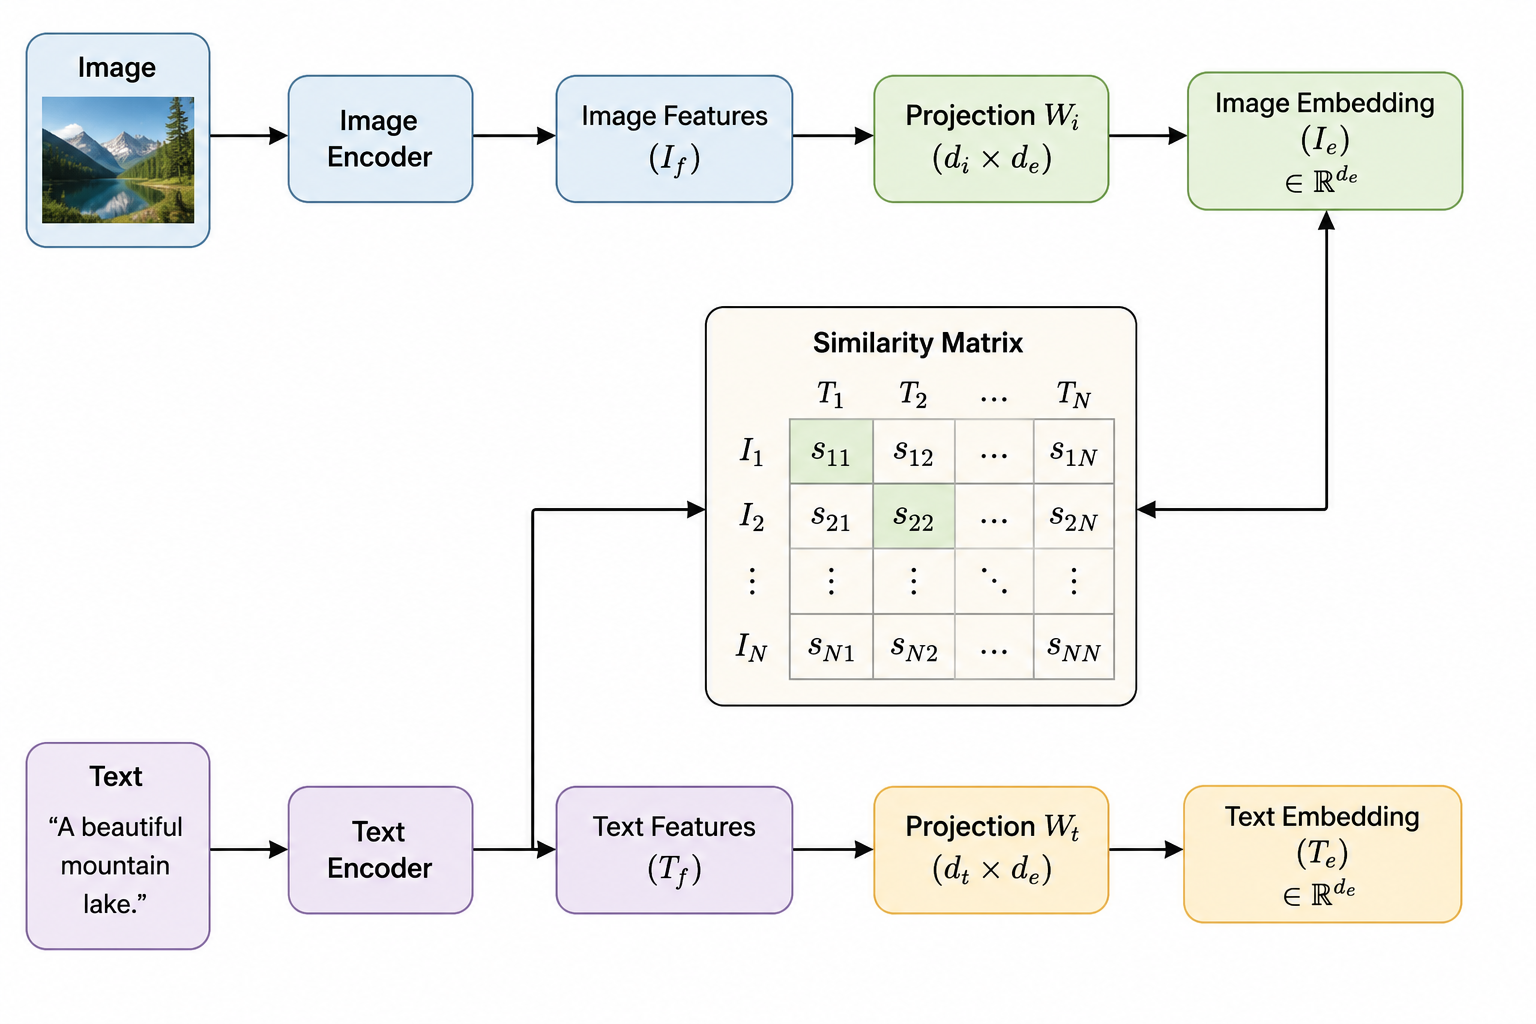

In [ ]:
import torch.nn as nn


class CLIP(nn.Module):
    def __init__(self, d_i: int, d_t: int, d_e: int, image_encoder: ImageEncoder,
                 text_encoder: TextEncoder):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        self.W_i = nn.Parameter(torch.empty((self.image_encoder.d_i, d_e), dtype=torch.float32))
        self.W_t = nn.Parameter(torch.empty((self.text_encoder.d_t, d_e), dtype=torch.float32))
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))


    def initialize_parameters(self):
        self.W_i = nn.init.normal_(self.W_i, mean=0.0, std=0.02)
        self.W_t = nn.init.normal_(self.W_t, mean=0.0, std=0.02)


    def forward(self, I: torch.Tensor, T:torch.Tensor):
        I_f = self.image_encoder.encode(I)
        T_f = self.text_encoder.encode(T)

        I_e = l2_norm(torch.tensordot(I_f, self.W_i, dims=1))
        T_e = l2_norm(torch.tensordot(T_f, self.W_t, dims=1))

        # exp(log(x)) = x
        logits_image = (I_e @ T_e.T) * self.logit_scale.exp()
        logits_text = logits_image.t()

        return logits_image, logits_text

In [ ]:
def create_float_tensor(values: List[Any]):
    return torch.tensor(values,
         dtype=torch.float32,
         device=device
    )

"""each image at index i is paired with the text at index i, and the other combinations are
treated as negatives during training. """

I = create_float_tensor([
    [ [[1, 2], [3, 4]], [[10, 20], [1, 2]], [[2, 5], [6, 8]] ],  # Image 1
    [ [[10, 20], [35, 4]], [[1, 20], [1, 22]], [[2, 8], [4, 8]] ],  # Image 2
    [ [[1, 5], [45, 4]], [[100, 20], [9, 22]], [[2, 8], [14.8, 8]] ],  # Image 3
    [ [[1, 5], [4, 8]], [[1, 20], [9, 25]], [[6, 8], [10.8, 8]] ],  # Image 4
    ])

T = create_float_tensor([
    [1, 2, 3, 4],  # Text 1
    [6, 5, 2, 19],  # Text 2
    [8, 3, 19, 22],  # Text 3
    [2, 3, 1, 22],  # Text 4
    ])

batch_size = 2
d_i = 3  #  Randomly Created image embedding dimensional
d_t = 5  #  Randomly Created text embedding dimensional
d_e = 4  # Shared Embedding space dim

In [ ]:
image_encoder = DummyImageEncoder(d_i)
text_encoder = DummyTextEncoder(d_t)

clip = CLIP(d_i, d_t, d_e, image_encoder, text_encoder)
clip.initialize_parameters() #  Initilize the W_i and W_t weight paramter
clip.to(device)

optimizer = torch.optim.Adam(clip.parameters(), lr=1e-2)

for i in range(0, I.size(0), batch_size):
    logits_image, logits_text = clip.forward(I[i: i + batch_size], T[i: i + batch_size])
    loss = calc_clip_cross_entropy_loss(logits_image, logits_text, range(logits_image.size(0)))

    optimizer.zero_grad()#  Clear previous gradients
    loss.backward() # Calcuate gradients for model parameters
    optimizer.step() # Update parameters using gradients

    print(f"Step {i}, Loss: {loss.item():.4f}")


Step 0, Loss: 1.5506
Step 2, Loss: 8.0252


In [ ]:
from torch.testing import assert_close


def test_l2_norm_unit_norm():
    x = torch.randn(4, 5)
    x_norm = l2_norm(x)
    norms = x_norm.norm(p=2, dim=1)

    assert_close(norms, torch.ones_like(norms))

def test_softmax():
    logits = torch.randn(3, 4)
    probs = softmax(logits)
    row_sums = probs.sum(dim=1)
    assert_close(row_sums, torch.ones_like(row_sums))

def test_cross_entropy():
    logits_softmax = torch.tensor([
        [0.1, 0.5, 0.4],
        [0.25, 0.25, 0.25],
        [0.2, 0.5, 0.3]
    ])
    ce = calc_cross_entropy(logits_softmax)
    assert_close(ce, torch.tensor(1.6309508))

def test_clip_cross_entropy():
    logits = torch.tensor([
        [10.0, 1.0, 0.1],
        [1.0, 10.0, 0.1],
        [0.1, 1.0, 10.0]
    ])
    loss = calc_clip_cross_entropy_loss(logits, logits.t())

    assert_close(loss, torch.tensor(0.00017))


test_l2_norm_unit_norm()
test_softmax()
test_cross_entropy()
test_clip_cross_entropy()